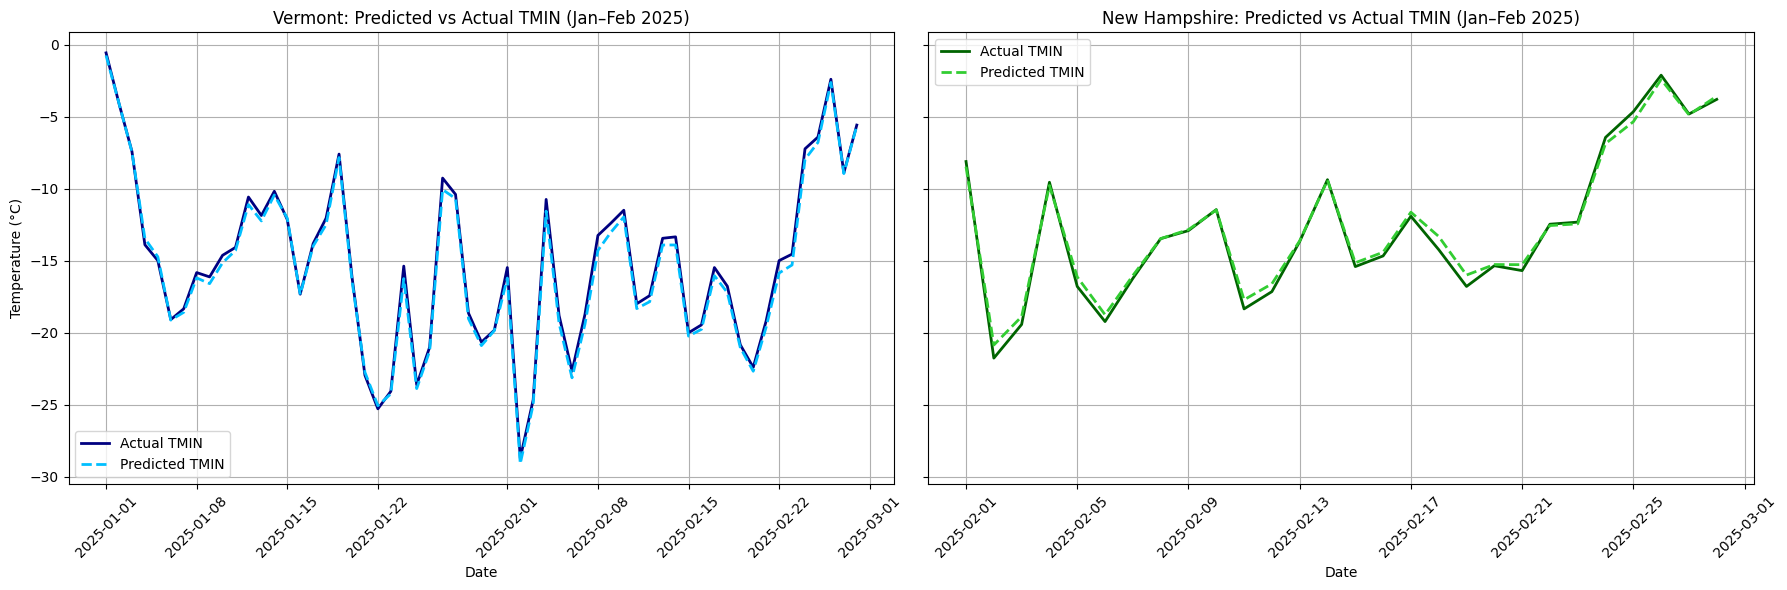

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Vermont
vermont_df = pd.read_csv('/workspaces/BlizzardX/Notebooks/Vermont_Predicted_Actual_JanFeb2025.csv')
vermont_df['DATE'] = pd.to_datetime(vermont_df['DATE'])

# Load New Hampshire
nh_df = pd.read_csv('/workspaces/BlizzardX/Notebooks/NewHampshire_Predicted_Actual_JanFeb2025.csv')
nh_df['DATE'] = pd.to_datetime(nh_df['DATE'])


# Group by Date, average across stations
vermont_avg = vermont_df.groupby('DATE').agg({'Predicted_TMIN': 'mean', 'Actual_TMIN': 'mean'}).reset_index()
nh_avg = nh_df.groupby('DATE').agg({'Predicted_TMIN': 'mean', 'Actual_TMIN': 'mean'}).reset_index()

# Plot side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

# Vermont Plot
ax1.plot(vermont_avg['DATE'], vermont_avg['Actual_TMIN'], label='Actual TMIN', color='navy', linewidth=2)
ax1.plot(vermont_avg['DATE'], vermont_avg['Predicted_TMIN'], label='Predicted TMIN', color='deepskyblue', linestyle='--', linewidth=2)
ax1.set_title('Vermont: Predicted vs Actual TMIN (Jan–Feb 2025)')
ax1.set_xlabel('Date')
ax1.set_ylabel('Temperature (°C)')
ax1.grid(True)
ax1.legend()
ax1.tick_params(axis='x', rotation=45)

# New Hampshire Plot
ax2.plot(nh_avg['DATE'], nh_avg['Actual_TMIN'], label='Actual TMIN', color='darkgreen', linewidth=2)
ax2.plot(nh_avg['DATE'], nh_avg['Predicted_TMIN'], label='Predicted TMIN', color='limegreen', linestyle='--', linewidth=2)
ax2.set_title('New Hampshire: Predicted vs Actual TMIN (Jan–Feb 2025)')
ax2.set_xlabel('Date')
ax2.grid(True)
ax2.legend()
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [1]:
import pandas as pd
import numpy as np

# Load your CSVs
vermont_df = pd.read_csv("/workspaces/BlizzardX/Notebooks/Vermont_Predicted_Actual_JanFeb2025.csv")
nh_df = pd.read_csv("/workspaces/BlizzardX/Notebooks/NewHampshire_Predicted_Actual_JanFeb2025.csv")

# Ensure DATE column is datetime
vermont_df['DATE'] = pd.to_datetime(vermont_df['DATE'])
nh_df['DATE'] = pd.to_datetime(nh_df['DATE'])

# Define MAE-based margins for prediction intervals
vermont_margin = 0.38  # From model evaluation
nh_margin = 0.43       # From model evaluation

# Add Prediction Intervals
vermont_df['Lower_Bound_TMIN'] = vermont_df['Predicted_TMIN'] - vermont_margin
vermont_df['Upper_Bound_TMIN'] = vermont_df['Predicted_TMIN'] + vermont_margin

nh_df['Lower_Bound_TMIN'] = nh_df['Predicted_TMIN'] - nh_margin
nh_df['Upper_Bound_TMIN'] = nh_df['Predicted_TMIN'] + nh_margin

# Define 10th percentile cutoff for cold event threshold
vermont_cutoff = vermont_df['Predicted_TMIN'].quantile(0.10)
nh_cutoff = nh_df['Predicted_TMIN'].quantile(0.10)

# Cold Event Probability Function
def calculate_cold_event_probability(pred_tmin, threshold):
    diff = threshold - pred_tmin
    prob = np.clip(diff / 10, 0, 1)
    return prob * 100  # Convert to percentage

# Apply Cold Event Probabilities
vermont_df['Cold_Event_Probability'] = vermont_df['Predicted_TMIN'].apply(lambda x: calculate_cold_event_probability(x, vermont_cutoff))
nh_df['Cold_Event_Probability'] = nh_df['Predicted_TMIN'].apply(lambda x: calculate_cold_event_probability(x, nh_cutoff))

# Save enhanced CSVs
vermont_df.to_csv("Vermont_ColdEvent_Enhanced.csv", index=False)
nh_df.to_csv("NewHampshire_ColdEvent_Enhanced.csv", index=False)

print("✅ Enhanced CSVs with Prediction Intervals and Cold Event Probabilities saved successfully.")


✅ Enhanced CSVs with Prediction Intervals and Cold Event Probabilities saved successfully.
